In [1]:
import warnings
from collections import Counter
from itertools import combinations
from typing import Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from sklearn.base import clone
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.feature_selection import RFECV
from sklearn.metrics import recall_score
from sklearn.model_selection import KFold, train_test_split
from sklearn.neighbors import LocalOutlierFactor

warnings.filterwarnings("ignore")

/Users/maxim/Documents/work/Exam_20_08_2026_3/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
pd.set_option('display.max_colwidth', None)

Setting the constants for this notebook and setting up the dataframe

`OUTER_SPLITS` is used to create different train/test splits
`INNER_SPLITS` is used to set the k-fold for RFECV to select the features

In [3]:
RANDOM_STATE = 42
TARGET_COL = "Outcome"

# Serology results, blood counts, temperature and fever duration separate the two Outcome
# classes almost perfectly (see 00_model), so they are dropped here as well.
LEAKAGE_COLS = [
    "NS1",
    "IgG",
    "IgM",
    "Platelet_Count",
    "WBC_Count",
    "Body_Temperature",
    "Fever_Duration",
]

CATEGORICAL_COLS = ["Gender", "AreaType", "HouseType", "Joint_Pain"]

# best outlier setup picked in 04_Outlier_Method
OUTLIER_PARAMS = {"n_neighbors": 20, "leaf_size": 30, "contamination": 0.05}

OUTER_SPLITS = 5
INNER_SPLITS = 3

df = pd.read_csv("data.csv")
df = df.rename(columns=lambda x: x.strip())
df = df.drop(columns=[col for col in LEAKAGE_COLS + ["District"] if col in df.columns])

# poverty rate of the thana the patient lives in (see 03_Feature_Engineering)
poverty = pd.read_csv("area_poverty_table.csv")
df["Area_HCR"] = df["Area"].map(poverty.set_index("Area")["HCR_upper_2022"])
df.head()

,Gender,Age,Area,AreaType,HouseType,Joint_Pain,Headache,Retro_Orbital_Pain,Myalgia,Rash,Outcome,Area_HCR
0,Female,45,Mirpur,Undeveloped,Building,Severe,0,0,1,0.0,0,12.6
1,Male,17,Chawkbazar,Developed,Building,NaN,1,0,0,0.0,0,7.5
2,Female,29,Paltan,Undeveloped,Other,NaN,0,0,0,0.0,0,1.0
3,Female,63,Motijheel,Developed,Other,Moderate,0,0,1,0.0,1,3.6
4,Male,22,Gendaria,Undeveloped,Building,NaN,0,0,0,0.0,0,2.4


Creating binning and outlier filtering functions

In [4]:
def add_area_binning(df: pd.DataFrame, poverty_df: pd.DataFrame, n_bins: int = 5) -> pd.DataFrame:
    out = df.copy()

    areas = (
        out[["Area", "Outcome"]]
        .dropna(subset=["Area"])
        .groupby("Area", as_index=False)
        .agg(n_patients=("Outcome", "size"))
        .merge(poverty_df[["Area", "HCR_upper_2022"]], on="Area", how="left")
        .sort_values(["HCR_upper_2022", "Area"], kind="mergesort")
        .reset_index(drop=True)
    )

    def find_balanced_cuts(sizes, n_bins=5):
        sizes = np.asarray(sizes, dtype=float)
        cumulative = np.concatenate([[0], sizes.cumsum()])
        target = sizes.sum() / n_bins

        best_score, best_bounds = None, None
        for cuts in combinations(range(1, len(sizes)), n_bins - 1):
            bounds = (0,) + cuts + (len(sizes),)
            counts = np.diff(cumulative[list(bounds)])
            deviations = np.abs(counts - target)
            score = (deviations.max(), (deviations ** 2).sum())
            if best_score is None or score < best_score:
                best_score, best_bounds = score, bounds

        return list(best_bounds), best_score

    bounds, _ = find_balanced_cuts(areas["n_patients"].values, n_bins=n_bins)

    inner_edges = [
        round(
            (areas.loc[b - 1, "HCR_upper_2022"] + areas.loc[b, "HCR_upper_2022"]) / 2,
            3,
        )
        for b in bounds[1:-1]
    ]

    bin_edges = [-np.inf] + inner_edges + [np.inf]
    bin_labels = [f"Q{i}" for i in range(1, n_bins + 1)]

    area_to_hcr = poverty_df.set_index("Area")["HCR_upper_2022"]
    out["Area_HCR"] = out["Area"].map(area_to_hcr)
    out["Area_bin"] = pd.cut(
        out["Area_HCR"],
        bins=bin_edges,
        labels=bin_labels,
        ordered=True,
    )

    out["Area_bin_code"] = out["Area_bin"].cat.codes
    out = out.drop(columns=["Area_bin", "Area_HCR"])

    return out


def add_age_binning(df: pd.DataFrame, balance_tolerance: float = 0.10) -> pd.DataFrame:
    """Add Age_bin using the same balanced-split logic from Feature_Engineering.ipynb."""
    out = df.copy()

    age_counts = (
        out.groupby("Age")
        .agg(n_patients=("Outcome", "size"), positive_rate=("Outcome", "mean"))
        .sort_index()
    )

    def enumerate_splits(n_groups, n_bins):
        return np.array(
            [(0,) + cuts + (n_groups,) for cuts in combinations(range(1, n_groups), n_bins - 1)],
            dtype=np.int32,
        )

    def score_splits(splits, group_sizes, group_positives):
        group_sizes = np.asarray(group_sizes, dtype=float)
        group_positives = np.asarray(group_positives, dtype=float)
        cum_n = np.concatenate([[0], group_sizes.cumsum()])
        cum_p = np.concatenate([[0], group_positives.cumsum()])

        n = np.diff(cum_n[splits], axis=1)
        p = np.diff(cum_p[splits], axis=1)
        total_n, total_p = group_sizes.sum(), group_positives.sum()
        target = total_n / (splits.shape[1] - 1)

        expected_pos = n * total_p / total_n
        expected_neg = n * (total_n - total_p) / total_n
        with np.errstate(divide="ignore", invalid="ignore"):
            chi2 = np.nan_to_num(
                (p - expected_pos) ** 2 / expected_pos + ((n - p) - expected_neg) ** 2 / expected_neg
            ).sum(axis=1)

        rates = np.divide(p, n, out=np.full_like(p, np.nan), where=n > 0)
        return {
            "n": n,
            "rates": rates,
            "balance_deviation": np.abs(n - target).max(axis=1),
            "rate_spread": np.nanmax(rates, axis=1) - np.nanmin(rates, axis=1),
            "chi2": chi2,
        }

    age_values = age_counts.index.to_numpy()
    age_sizes = age_counts["n_patients"].to_numpy()
    age_positives = out.groupby("Age")["Outcome"].sum().sort_index().to_numpy()

    splits = enumerate_splits(len(age_values), 5)
    scores = score_splits(splits, age_sizes, age_positives)

    tol = balance_tolerance * len(out) / 5
    allowed = np.where(scores["balance_deviation"] <= tol)[0]
    if len(allowed) == 0:
        raise ValueError("No age split satisfies the balance tolerance.")

    chosen = allowed[scores["chi2"][allowed].argmax()]
    age_bounds = splits[chosen]

    age_edges = [-np.inf] + [(age_values[b - 1] + age_values[b]) / 2 for b in age_bounds[1:-1]] + [np.inf]
    age_labels = [
        f"{age_values[age_bounds[i]]}-{age_values[age_bounds[i + 1] - 1]}"
        for i in range(5)
    ]

    out["Age_bin"] = pd.cut(out["Age"], bins=age_edges, labels=age_labels, ordered=True)
    out = pd.get_dummies(out, columns=["Age_bin"], drop_first=True, dtype=int)
    return out


def split_train_val_test(
    df: pd.DataFrame,
    random_state: int = RANDOM_STATE,
    ) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """80 / 10 / 10 split with a fixed seed, so every notebook can rebuild the same subsets.

    The test subset is returned untouched and must not take part in any selection step.
    """
    df_dev, df_test = train_test_split(df, test_size=0.1, random_state=random_state)
    df_train, df_val = train_test_split(df_dev, test_size=1 / 9, random_state=random_state)
    return df_train, df_val, df_test


def prepare_features(df: pd.DataFrame, reference: pd.DataFrame) -> pd.DataFrame:
    """Fill the missing values and one-hot encode the categorical columns.

    Every fill value comes from `reference` (the training + validation rows), so no statistic
    of the untouched test subset ever reaches the frames used below.
    """
    out = df.copy()

    # A missing Joint_Pain means the symptom was not reported (see 02_Missing_Values)
    out["Joint_Pain"] = out["Joint_Pain"].fillna("None")
    for col in out.select_dtypes(include="number"):
        out[col] = out[col].fillna(reference[col].median())
    for col in CATEGORICAL_COLS:
        out[col] = out[col].fillna(reference[col].mode()[0])

    return pd.get_dummies(out, columns=CATEGORICAL_COLS, drop_first=True, dtype=int)


def apply_binning(
    df: pd.DataFrame,
    poverty_path: str = "area_poverty_table.csv",
    ) -> pd.DataFrame:
    """The binning picked in 00_model: one ordinal Area column, one-hot Age bins.

    Area_HCR and the raw Age column are dropped, so only the binned versions reach the models.
    """
    poverty = pd.read_csv(poverty_path)
    df_binned = add_area_binning(df, poverty, n_bins=5)
    df_binned = add_age_binning(df_binned, balance_tolerance=0.10)
    return df_binned.drop(columns=["Area", "Age"])


def apply_outlier_filter(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    random_state: int = RANDOM_STATE,
    ) -> Tuple[pd.DataFrame, pd.Series]:
    detector = LocalOutlierFactor(**OUTLIER_PARAMS)
    labels = detector.fit_predict(X_train)

    mask = pd.Series(labels == 1, index=X_train.index)
    X_filtered = X_train.loc[mask].copy()
    y_filtered = y_train.loc[mask].copy()
    return X_filtered, y_filtered

Iterating over outer folds to select the best features from the dataset

Using `RFECV` we extract only the useful features in the given context. For each number of features we can see the performance to choose at which threshold we can stop adding more features.

train: 800 | val: 100 | test (untouched): 100


Nested CV: 100%|██████████| 5/5 [00:10<00:00,  2.02s/it]


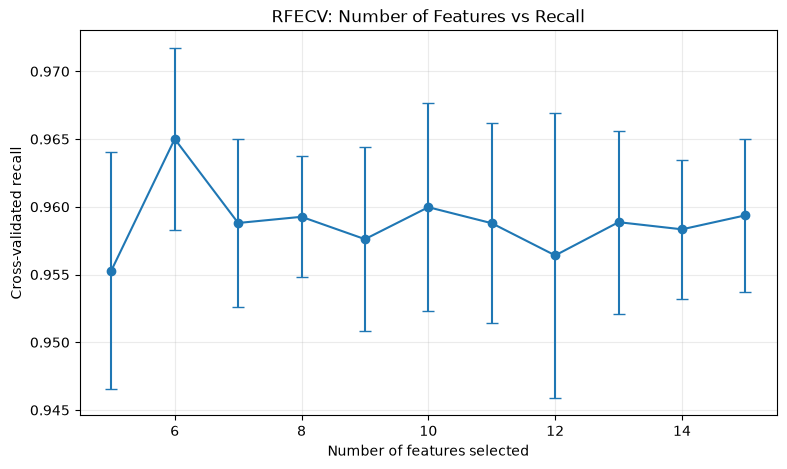

,fold,outer_fold_recall,selected_feature_count,selected_features,train_rows_after_outlier_filter
0,2,0.978947,6,"[Headache, Retro_Orbital_Pain, Myalgia, Rash, Joint_Pain_None, Joint_Pain_Severe]",684
1,4,0.956989,6,"[Headache, Retro_Orbital_Pain, Myalgia, Rash, Joint_Pain_None, Joint_Pain_Severe]",684
2,3,0.955556,9,"[Headache, Retro_Orbital_Pain, Myalgia, Rash, Gender_Male, HouseType_Other, Joint_Pain_None, Joint_Pain_Severe, Area_bin_code]",684
3,1,0.947917,6,"[Headache, Retro_Orbital_Pain, Myalgia, Rash, Joint_Pain_None, Joint_Pain_Severe]",685
4,5,0.941176,6,"[Headache, Retro_Orbital_Pain, Myalgia, Rash, Joint_Pain_None, Joint_Pain_Severe]",684


In [5]:
# 80 / 10 / 10, fixed seed on both splits: the test subset is put aside and never touched again
df_train_raw, df_val_raw, df_test_raw = split_train_val_test(df, RANDOM_STATE)

# imputation, encoding and binning are all fitted on the training + validation rows only
df_dev_raw = pd.concat([df_train_raw, df_val_raw], axis=0)
df_dev = apply_binning(prepare_features(df_dev_raw, reference=df_dev_raw))

print(f"train: {len(df_train_raw)} | val: {len(df_val_raw)} | test (untouched): {len(df_test_raw)}")

X = df_dev.drop(columns=[TARGET_COL]).copy()
y = df_dev[TARGET_COL].copy()

outer_cv = KFold(n_splits=OUTER_SPLITS, shuffle=True, random_state=RANDOM_STATE)
inner_cv = KFold(n_splits=INNER_SPLITS, shuffle=True, random_state=RANDOM_STATE)

base_estimator = GradientBoostingClassifier(random_state=RANDOM_STATE)

outer_fold_rows = []
curve_rows = []
selection_counter = Counter()
best_fold = None

for fold_id, (train_idx, val_idx) in enumerate(
    tqdm(outer_cv.split(X), total=OUTER_SPLITS, desc="Nested CV"),
    start=1,
 ):
    X_train = X.iloc[train_idx].copy()
    X_val = X.iloc[val_idx].copy()
    y_train = y.iloc[train_idx].copy()
    y_val = y.iloc[val_idx].copy()

    X_train_f, y_train_f = apply_outlier_filter(X_train, y_train, random_state=RANDOM_STATE)

    if X_train_f.isna().sum().sum() > 0 or X_val.isna().sum().sum() > 0:
        raise ValueError("NaNs detected after preprocessing")

    rfecv = RFECV(
        estimator=clone(base_estimator),
        step=1,
        min_features_to_select=5,
        cv=inner_cv,
        scoring="recall",
        n_jobs=-1,
    )
    rfecv.fit(X_train_f, y_train_f)

    if rfecv.n_features_ < 1:
        raise ValueError("RFECV selected fewer than one feature")

    selected_features = X_train_f.columns[rfecv.support_].tolist()
    selection_counter.update(selected_features)

    model = clone(base_estimator)
    model.fit(rfecv.transform(X_train_f), y_train_f)
    y_pred = model.predict(rfecv.transform(X_val))
    fold_recall = recall_score(y_val, y_pred)

    outer_fold_rows.append(
        {
            "fold": fold_id,
            "outer_fold_recall": fold_recall,
            "selected_feature_count": rfecv.n_features_,
            "selected_features": selected_features,
            "train_rows_after_outlier_filter": len(X_train_f),
        }
    )

    n_features_grid = rfecv.cv_results_.get("n_features")
    if n_features_grid is None:
        n_features_grid = np.arange(1, len(rfecv.cv_results_["mean_test_score"]) + 1)

    curve_rows.append(
        pd.DataFrame(
            {
                "fold": fold_id,
                "n_features": n_features_grid,
                "recall": rfecv.cv_results_["mean_test_score"],
            }
        )
    )

    if best_fold is None or fold_recall > best_fold["outer_fold_recall"]:
        best_fold = {
            "fold": fold_id,
            "outer_fold_recall": fold_recall,
            "selected_feature_count": rfecv.n_features_,
            "selected_features": selected_features,
        }

outer_results = (
    pd.DataFrame(outer_fold_rows)
    .sort_values("outer_fold_recall", ascending=False)
    .reset_index(drop=True)
 )
curve_results = pd.concat(curve_rows, ignore_index=True)
curve_summary = (
    curve_results.groupby("n_features", as_index=False)
    .agg(mean_recall=("recall", "mean"), std_recall=("recall", "std"))
    .sort_values("n_features")
 )
curve_summary["std_recall"] = curve_summary["std_recall"].fillna(0.0)

plt.figure(figsize=(9, 5))
plt.errorbar(
    curve_summary["n_features"],
    curve_summary["mean_recall"],
    yerr=curve_summary["std_recall"],
    fmt="o-",
    capsize=4,
 )
plt.xlabel("Number of features selected")
plt.ylabel("Cross-validated recall")
plt.title("RFECV: Number of Features vs Recall")
plt.grid(alpha=0.25)
plt.show()

outer_results.head()

From the chart above we can see the number of features vs the CV recall. Recall rises up until 6 features, after which it drops and then plateus. Somewhere in the range 6-10 would be the ideal number of features. 

Before choosing the right number, let us see how often each feature appears in the features list chosen by RFECV.

In [6]:
stability_df = (
    pd.DataFrame(
        {
            "feature": list(selection_counter.keys()),
            "selected_in_outer_folds": list(selection_counter.values()),
        }
    )
    .sort_values("selected_in_outer_folds", ascending=False)
    .reset_index(drop=True)
 )
stability_df["selection_rate"] = (
    stability_df["selected_in_outer_folds"] / OUTER_SPLITS
 )

print("\nFeature stability across outer folds:")
display(stability_df.head(20))


Feature stability across outer folds:


,feature,selected_in_outer_folds,selection_rate
0,Headache,5,1.0
1,Retro_Orbital_Pain,5,1.0
2,Myalgia,5,1.0
3,Rash,5,1.0
4,Joint_Pain_None,5,1.0
5,Joint_Pain_Severe,5,1.0
6,Gender_Male,1,0.2
7,HouseType_Other,1,0.2
8,Area_bin_code,1,0.2


We can see that the top 6 features appear in all feature splits. This means that the following features are important for the model to perform well.

To choose the optimal number of features, we will use the 1-Standard Error rule. The steps are as following:

1) Choose the number of features for which the recall is the highest.
2) Calculate the standard error for our data: `se = sum(stddev) / sqrt(num_observations)`
3) Choose the smallest number of features for which the difference between the best recall and the given recall is within standard error

The resulting number of features would result in recall that is within standard error range of the best recall

The graph shows this process in a visual manner. It can be visually seen that recall falls within standard error range when number of features is equal to 6. Since we have 6 features that appear in all feature extraction list, we can train the model on those 6 features.

1-SE rule summary
- k_best (highest mean recall): 6
- mean recall at k_best: 0.9650
- SE at k_best: 0.0030
- 1-SE recall threshold: 0.9620
- k_1se (smallest k within threshold): 6
- Outer CV mean recall across folds: 0.9561 +/- 0.0143

Recommended features for tuning using the 1-SE rule:
  * Headache
  * Retro_Orbital_Pain
  * Myalgia
  * Rash
  * Joint_Pain_None
  * Joint_Pain_Severe


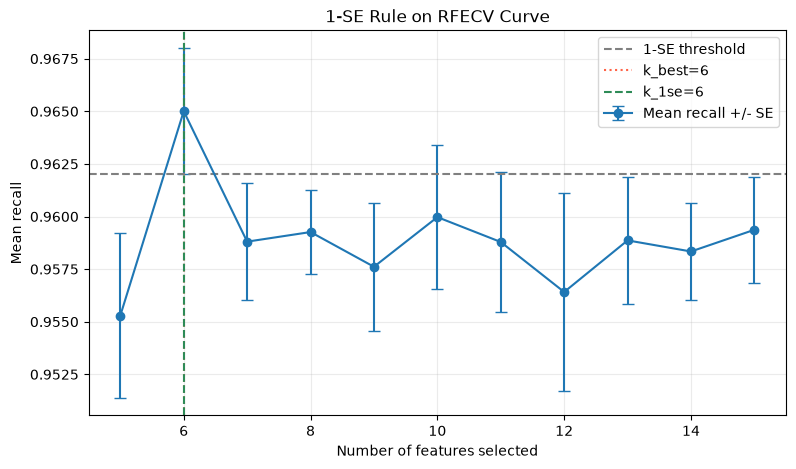

,n_features,mean_recall,std_recall,n_obs,se_recall,within_1se
0,5,0.955292,0.008758,5,0.003917,False
1,6,0.965006,0.006716,5,0.003004,True
2,7,0.958806,0.006215,5,0.002780,False
3,8,0.959262,0.004470,5,0.001999,False
4,9,0.957612,0.006806,5,0.003044,False
5,10,0.959972,0.007658,5,0.003425,False
6,11,0.958789,0.007397,5,0.003308,False
7,12,0.956413,0.010524,5,0.004707,False
8,13,0.958866,0.006764,5,0.003025,False
9,14,0.958339,0.005124,5,0.002291,False


In [7]:
se_summary = (
    curve_results.groupby("n_features", as_index=False)
    .agg(
        mean_recall=("recall", "mean"),
        std_recall=("recall", "std"),
        n_obs=("recall", "count"),
    )
    .sort_values("n_features")
    .reset_index(drop=True)
)
se_summary["std_recall"] = se_summary["std_recall"].fillna(0.0)
se_summary["se_recall"] = se_summary["std_recall"] / np.sqrt(se_summary["n_obs"])

best_row = se_summary.loc[se_summary["mean_recall"].idxmax()]
k_best = int(best_row["n_features"])
best_mean_recall = float(best_row["mean_recall"])
best_se = float(best_row["se_recall"])
recall_threshold = best_mean_recall - best_se

candidate_rows = se_summary.loc[se_summary["mean_recall"] >= recall_threshold].copy()
k_1se = int(candidate_rows["n_features"].min())
se_summary["within_1se"] = se_summary["mean_recall"] >= recall_threshold

print("1-SE rule summary")
print(f"- k_best (highest mean recall): {k_best}")
print(f"- mean recall at k_best: {best_mean_recall:.4f}")
print(f"- SE at k_best: {best_se:.4f}")
print(f"- 1-SE recall threshold: {recall_threshold:.4f}")
print(f"- k_1se (smallest k within threshold): {k_1se}")

overall_outer_mean_recall = float(outer_results["outer_fold_recall"].mean())
overall_outer_std_recall = float(outer_results["outer_fold_recall"].std(ddof=1))
print(
    f"- Outer CV mean recall across folds: "
    f"{overall_outer_mean_recall:.4f} +/- {overall_outer_std_recall:.4f}"
)

recommended_features_1se = (
    stability_df.sort_values("selected_in_outer_folds", ascending=False)["feature"]
    .head(k_1se)
    .tolist()
)
print("\nRecommended features for tuning using the 1-SE rule:")
for f in recommended_features_1se:
    print(f"  * {f}")

plt.figure(figsize=(9, 5))
plt.errorbar(
    se_summary["n_features"],
    se_summary["mean_recall"],
    yerr=se_summary["se_recall"],
    fmt="o-",
    capsize=4,
    label="Mean recall +/- SE",
)
plt.axhline(recall_threshold, linestyle="--", color="gray", label="1-SE threshold")
plt.axvline(k_best, linestyle=":", color="tomato", label=f"k_best={k_best}")
plt.axvline(k_1se, linestyle="--", color="seagreen", label=f"k_1se={k_1se}")
plt.xlabel("Number of features selected")
plt.ylabel("Mean recall")
plt.title("1-SE Rule on RFECV Curve")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

display(se_summary)